# 🌍 Global Air Pollution & Health Risk Analysis

Air pollution is one of the most critical environmental challenges affecting human health and ecosystems worldwide.  
This project analyzes global air quality data to identify pollution patterns, high-risk regions, and dominant pollutants.

### 🎯 Objectives:
- Identify the most polluted countries and cities
- Understand AQI distribution across regions
- Analyze contribution of different pollutants
- Detect relationships between pollutants
- Highlight regions requiring urgent environmental attention

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv(r"C:\Users\ASUS\Desktop\DAP\Pro1_Global_Air_Pollution\global air pollution dataset.csv")
df.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


## 📊 Dataset Overview

The dataset contains air quality information across multiple countries and cities.  
It includes AQI values and pollutant-specific indicators such as CO, NO2, Ozone, and PM2.5.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23036 non-null  object
 1   City                23462 non-null  object
 2   AQI Value           23463 non-null  int64 
 3   AQI Category        23463 non-null  object
 4   CO AQI Value        23463 non-null  int64 
 5   CO AQI Category     23463 non-null  object
 6   Ozone AQI Value     23463 non-null  int64 
 7   Ozone AQI Category  23463 non-null  object
 8   NO2 AQI Value       23463 non-null  int64 
 9   NO2 AQI Category    23463 non-null  object
 10  PM2.5 AQI Value     23463 non-null  int64 
 11  PM2.5 AQI Category  23463 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB


In [6]:
df.describe()

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000


In [7]:
df.nunique()

Country                 175
City                  23462
AQI Value               347
AQI Category              6
CO AQI Value             34
CO AQI Category           3
Ozone AQI Value         213
Ozone AQI Category        5
NO2 AQI Value            59
NO2 AQI Category          2
PM2.5 AQI Value         383
PM2.5 AQI Category        6
dtype: int64

## 🧹 Data Cleaning

To ensure accurate analysis:
- Missing values in Country and City columns are removed

In [9]:
df.isnull().sum()

Country               427
City                    1
AQI Value               0
AQI Category            0
CO AQI Value            0
CO AQI Category         0
Ozone AQI Value         0
Ozone AQI Category      0
NO2 AQI Value           0
NO2 AQI Category        0
PM2.5 AQI Value         0
PM2.5 AQI Category      0
dtype: int64

In [10]:
# Drop rows with missing values in 'Country' and 'City' columns
df = df.dropna(subset=['Country', 'City'])

In [11]:
df.isnull().sum()

Country               0
City                  0
AQI Value             0
AQI Category          0
CO AQI Value          0
CO AQI Category       0
Ozone AQI Value       0
Ozone AQI Category    0
NO2 AQI Value         0
NO2 AQI Category      0
PM2.5 AQI Value       0
PM2.5 AQI Category    0
dtype: int64

## 📈 AQI Distribution

This visualization shows how AQI values are distributed across all cities.

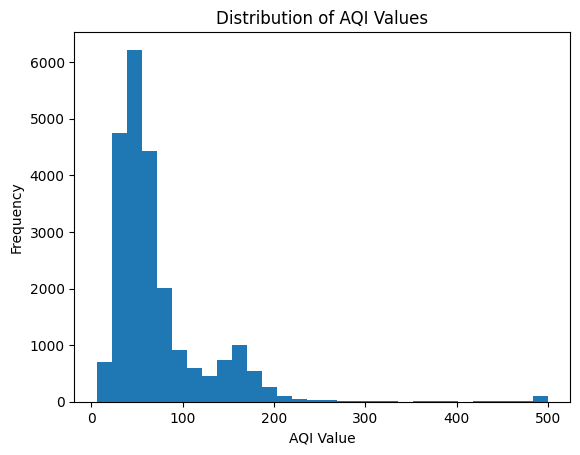

In [12]:
df['AQI Value'].plot(kind='hist', bins=30)
plt.title("Distribution of AQI Values")
plt.xlabel("AQI Value")
plt.show()

## 🌍 Top Polluted Countries

This analysis identifies countries with the highest average AQI levels.

In [13]:
top_countries = df.groupby('Country')['AQI Value'].mean().sort_values(ascending=False).head(10)
top_countries

Country
Republic of Korea       421.000000
Bahrain                 188.000000
Mauritania              179.000000
Pakistan                178.788274
United Arab Emirates    163.666667
Aruba                   163.000000
Kuwait                  162.000000
Qatar                   157.500000
India                   152.964228
Senegal                 152.424242
Name: AQI Value, dtype: float64

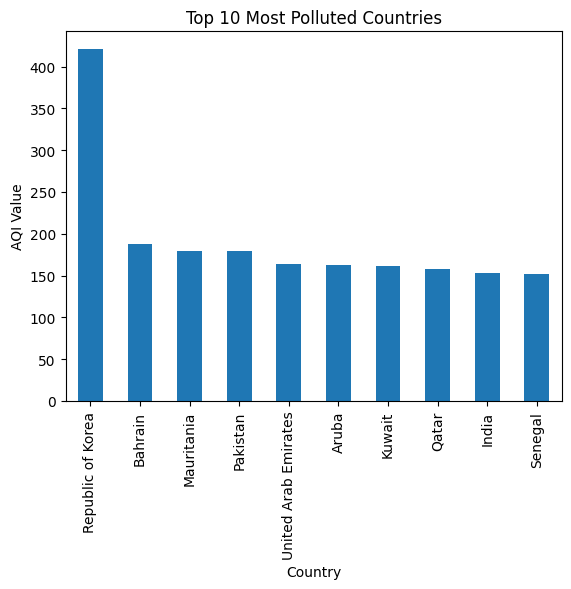

In [15]:
top_countries.plot(kind='bar')
plt.title("Top 10 Most Polluted Countries")
plt.ylabel("AQI Value")
plt.xticks(rotation=90)
plt.show()

## 🌿 Cleanest Countries

This shows countries with the lowest AQI levels.

In [16]:
clean_countries = df.groupby('Country')['AQI Value'].mean().sort_values().head(10)
clean_countries

Country
Palau                               16.000000
Solomon Islands                     18.000000
Maldives                            19.000000
Iceland                             23.000000
Bolivia (Plurinational State of)    23.787879
Papua New Guinea                    24.866667
Seychelles                          26.000000
Bhutan                              26.000000
Uruguay                             26.653846
Argentina                           28.235294
Name: AQI Value, dtype: float64

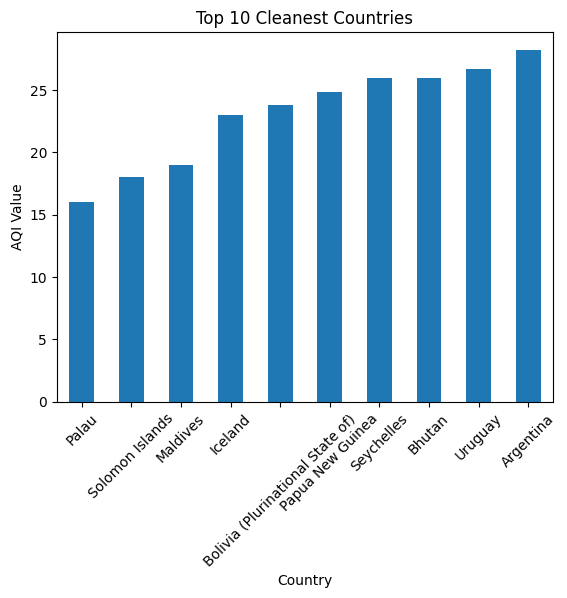

In [17]:
clean_countries.plot(kind='bar')
plt.title("Top 10 Cleanest Countries")
plt.ylabel("AQI Value")
plt.xticks(rotation=45)
plt.show()

## 🏙️ Top Polluted Cities

Identifies cities with the highest pollution levels.

In [18]:
top_cities = df.groupby('City')['AQI Value'].mean().sort_values(ascending=False).head(10)
top_cities

City
Dataganj        500.0
Chhachhrauli    500.0
Sasni           500.0
Rohtak          500.0
Faridabad       500.0
Nagaur          500.0
Bareli          500.0
Churu           500.0
Phalodi         500.0
Kakrala         500.0
Name: AQI Value, dtype: float64

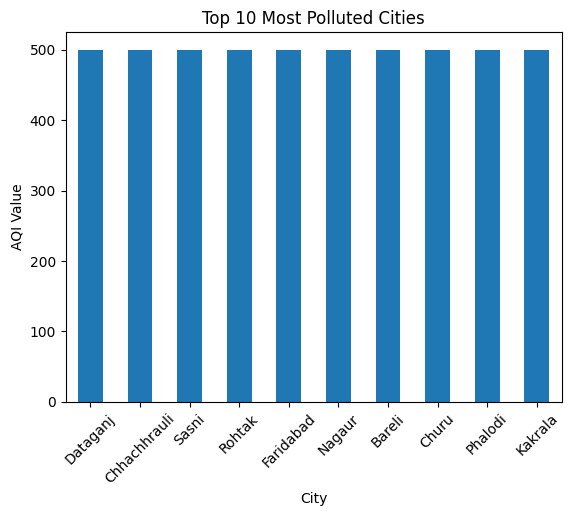

In [19]:
top_cities.plot(kind='bar')
plt.title("Top 10 Most Polluted Cities")
plt.ylabel("AQI Value")
plt.xticks(rotation=45)
plt.show()

## 🥧 AQI Category Distribution

Shows how cities are distributed across air quality categories.

In [20]:
aqi_dist = df['AQI Category'].value_counts()
aqi_dist

AQI Category
Good                              9688
Moderate                          9087
Unhealthy                         2215
Unhealthy for Sensitive Groups    1568
Very Unhealthy                     286
Hazardous                          191
Name: count, dtype: int64

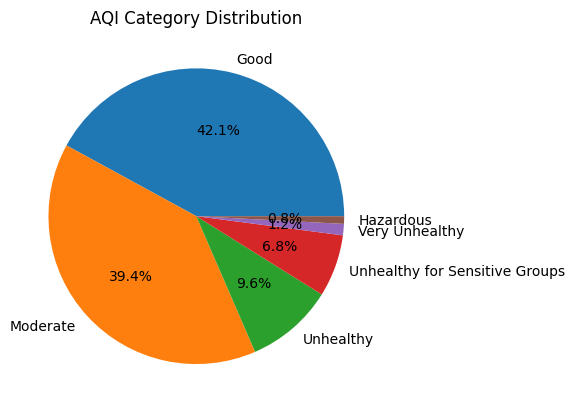

In [21]:
aqi_dist.plot(kind='pie', autopct='%1.1f%%')
plt.title("AQI Category Distribution")
plt.ylabel("")
plt.show()

## ☁️ Pollutant Contribution Analysis

Analyzes the average contribution of different pollutants to air quality.

In [22]:
pollutants = df[['CO AQI Value','Ozone AQI Value','NO2 AQI Value','PM2.5 AQI Value']].mean()
pollutants.sort_values(ascending=False)

PM2.5 AQI Value    68.883482
Ozone AQI Value    35.233905
NO2 AQI Value       3.084741
CO AQI Value        1.376254
dtype: float64

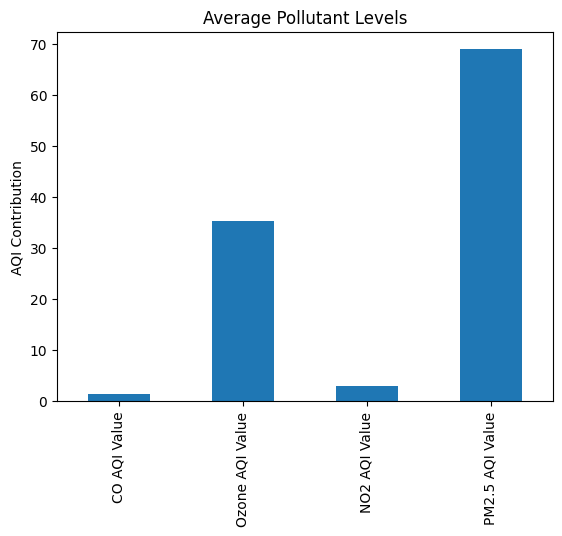

In [23]:
pollutants.plot(kind='bar')
plt.title("Average Pollutant Levels")
plt.ylabel("AQI Contribution")
plt.show()

## 🔗 Correlation Analysis

This heatmap shows relationships between AQI and pollutants.

In [32]:
corr = df[['AQI Value','CO AQI Value','Ozone AQI Value','NO2 AQI Value','PM2.5 AQI Value']].corr()
corr

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
AQI Value,1.000000,0.429643,0.405086,0.230845,0.984518
CO AQI Value,0.429643,1.000000,0.144838,0.487627,0.437751
Ozone AQI Value,0.405086,0.144838,1.000000,-0.182934,0.340488
NO2 AQI Value,0.230845,0.487627,-0.182934,1.000000,0.259084
PM2.5 AQI Value,0.984518,0.437751,0.340488,0.259084,1.000000


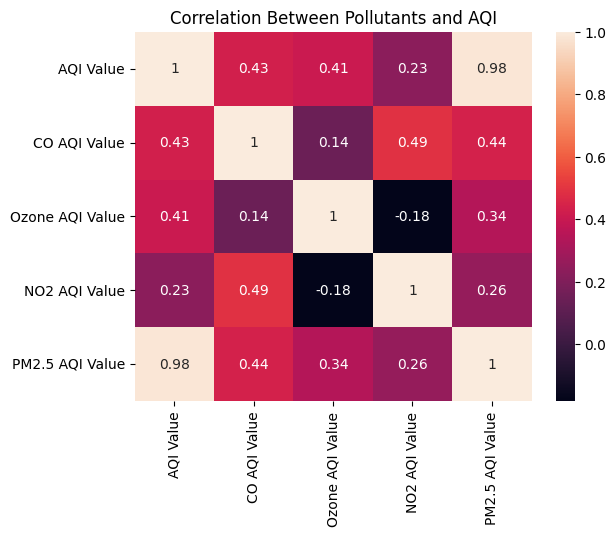

In [33]:

sns.heatmap(corr, annot=True)
plt.title("Correlation Between Pollutants and AQI")
plt.show()

## ⚙️ Pollution Score

A combined pollution score is created by summing all pollutant values.

In [25]:
df['Pollution Score'] = (
    df['CO AQI Value'] +
    df['Ozone AQI Value'] +
    df['NO2 AQI Value'] +
    df['PM2.5 AQI Value']
)

In [ ]:
# Top 10 most polluted countries based on Pollution Score
df.groupby('Country')['Pollution Score'].mean().sort_values(ascending=False).head(10)

Country
Republic of Korea       533.000000
Bahrain                 320.000000
United Arab Emirates    317.000000
Kuwait                  314.000000
Qatar                   289.000000
Pakistan                266.403909
Oman                    235.833333
Saudi Arabia            228.285714
China                   210.533333
Mauritania              208.250000
Name: Pollution Score, dtype: float64

## 🚨 Extreme Pollution Cases

Shows cities with the highest recorded AQI values.

In [27]:
df.sort_values(by='AQI Value', ascending=False).head(10)

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Pollution Score
21639,India,Jhunjhunun,500,Hazardous,1,Good,38,Good,0,Good,433,Hazardous,472
8832,India,Niwari,500,Hazardous,1,Good,46,Good,2,Good,492,Hazardous,541
1865,India,Pilkhuwa,500,Hazardous,2,Good,61,Moderate,2,Good,500,Hazardous,565
702,India,Jahangirpur,500,Hazardous,1,Good,49,Good,1,Good,493,Hazardous,544
1943,India,Siwani,500,Hazardous,1,Good,38,Good,0,Good,500,Hazardous,539
720,India,Kandhla,500,Hazardous,3,Good,53,Moderate,8,Good,500,Hazardous,564
13111,India,Sujangarh,500,Hazardous,1,Good,37,Good,0,Good,457,Hazardous,495
15591,India,Faridabad,500,Hazardous,1,Good,45,Good,2,Good,500,Hazardous,548
19572,India,Ganganagar,500,Hazardous,1,Good,42,Good,0,Good,424,Hazardous,467
18681,India,Mailani,500,Hazardous,2,Good,116,Unhealthy for Sensitive Groups,1,Good,471,Hazardous,590


## 🧠 Key Insights

- The **Republic of Korea** records the highest average AQI (421), followed by **Bahrain, Mauritania, and Pakistan**, indicating severe air pollution in specific regions, particularly across Asia and the Middle East.

- Multiple cities in **India**, including **Dataganj, Chhachhrauli, Sasni, Rohtak, Faridabad, Nagaur, Bareli, Churu, Phalodi, and Kakrala**, exhibit an AQI value of **500**, which represents the maximum on the AQI scale and indicates extremely hazardous air quality conditions.

- The AQI category distribution shows that a large proportion of cities fall under **Good (9,688)** and **Moderate (9,087)** categories. However, a significant number of cities still fall into **Unhealthy (2,215)** and higher categories, highlighting widespread air quality concerns.

- **PM2.5 emerges as the dominant pollutant**, with the highest average AQI value (68.88), significantly exceeding Ozone (35.23), NO2 (3.08), and CO (1.38).

- Correlation analysis reveals a **very strong positive relationship between AQI and PM2.5 (0.98)**, confirming that fine particulate matter is the primary driver of overall air pollution levels.

- Moderate correlations between pollutants such as **CO and NO2 (0.49)** suggest shared emission sources, likely related to vehicular and industrial activities.

## 🚨 Implications

- Countries with consistently high AQI levels, such as the Republic of Korea and Pakistan, face **serious public health risks**, including increased cases of respiratory and cardiovascular diseases.

- Cities recording AQI values of 500 represent **critical pollution hotspots** and require immediate intervention through stricter emission regulations, improved urban planning, and pollution control strategies.

- The dominance of PM2.5 highlights the need for **targeted control of particulate emissions**, particularly from vehicles, industrial activities, construction, and biomass burning.

- Populations living in cities categorized as **Unhealthy, Very Unhealthy, and Hazardous** are at significantly higher risk, especially vulnerable groups such as children, the elderly, and individuals with pre-existing health conditions.

- The global spread of moderate to high AQI levels indicates that air pollution is not a localized issue but a **widespread environmental challenge requiring coordinated policy efforts**.

- Addressing key pollutants like PM2.5 can lead to **substantial improvements in overall air quality**, making it a priority area for policymakers.

## 📊 Analytical Observations

- The extremely high correlation between AQI and PM2.5 (0.98) suggests that AQI values are heavily influenced by fine particulate matter, making it the most critical variable in air quality assessment.

- The noticeable gap between PM2.5 and other pollutants indicates that **pollution is not evenly distributed across pollutants**, but rather dominated by specific emission sources.

- The moderate correlation between CO and NO2 (0.49) points toward **common sources such as vehicular emissions and fossil fuel combustion**, providing insights into underlying pollution drivers.

- The negative correlation between Ozone and NO2 (-0.18) suggests **atmospheric chemical interactions**, where ozone formation may be influenced by nitrogen oxide levels and sunlight-driven reactions.

- The repeated occurrence of AQI values at the maximum level (500) across multiple cities indicates either **extreme pollution events or potential data capping**, which is an important consideration for data interpretation.

- The presence of both high and low AQI categories within the dataset reflects **significant regional disparities in air quality**, emphasizing the need for location-specific environmental strategies.

- The dataset highlights that while some regions maintain acceptable air quality, others face **severe and persistent pollution challenges**, indicating uneven environmental progress globally.